✅ Starting splitting dataset...

Leaf scald: 176 train | 44 val
Sheath Blight: 281 train | 71 val
Healthy Rice Leaf: 154 train | 39 val
Narrow Brown Leaf Spot: 100 train | 26 val
Leaf Blast: 288 train | 72 val
Rice Hispa: 208 train | 52 val
Brown Spot: 231 train | 58 val
Bacterial Leaf Blight: 180 train | 46 val

✅ Done splitting dataset!

📊 Number of classes: 8


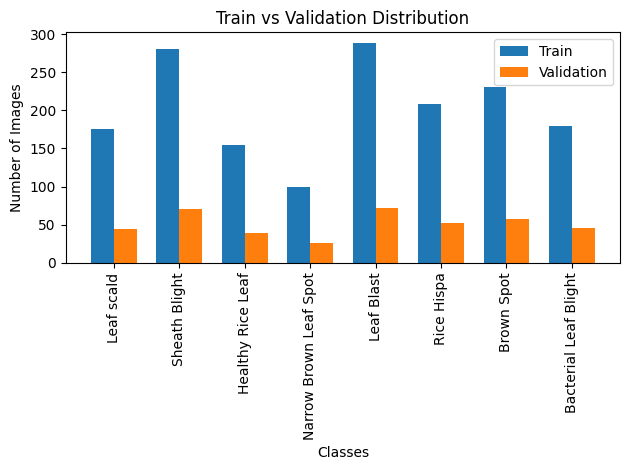

In [1]:
import os
import shutil
import random

# ========================
# CONFIG
# ========================
input_dir = "/kaggle/input/competitions/fptu-can-tho-olympic-ai-2026/train"          # Dir
output_dir = "/kaggle/working/dataset_split"   # Dir after split
split_ratio = 0.8              # 80% train, 20% val ratio
random.seed(42)

# ========================
# CREATE FOLDERS
# ========================
for split in ["train", "val"]:
    for class_name in os.listdir(input_dir):
        class_path = os.path.join(output_dir, split, class_name)
        os.makedirs(class_path, exist_ok=True)

# ========================
# SPLIT DATA
# ========================
class_order = []

print("✅ Starting splitting dataset...\n")
for class_name in os.listdir(input_dir):
    class_input_path = os.path.join(input_dir, class_name)

    if os.path.isdir(os.path.join(input_dir, class_name)):
        class_order.append(class_name)
    
    if not os.path.isdir(class_input_path):
        continue

    images = os.listdir(class_input_path)
    random.shuffle(images)

    split_point = int(len(images) * split_ratio)

    train_images = images[:split_point]
    val_images = images[split_point:]

    # Copy train
    for img in train_images:
        src = os.path.join(class_input_path, img)
        dst = os.path.join(output_dir, "train", class_name, img)
        shutil.copy2(src, dst)

    # Copy val
    for img in val_images:
        src = os.path.join(class_input_path, img)
        dst = os.path.join(output_dir, "val", class_name, img)
        shutil.copy2(src, dst)

    print(f"{class_name}: {len(train_images)} train | {len(val_images)} val")

print("\n✅ Done splitting dataset!\n")

# ========================
# CHECK NUMBER OF CLASSES
# ========================
num_classes = len(class_order)
print(f"📊 Number of classes: {num_classes}")

# ========================
# VISUALIZE DATA
# ========================
import matplotlib.pyplot as plt
import numpy as np

train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")

train_counts = {}
val_counts = {}

# Count images
for class_name in os.listdir(train_dir):
    train_class_path = os.path.join(train_dir, class_name)
    val_class_path = os.path.join(val_dir, class_name)

    if os.path.isdir(train_class_path):
        train_counts[class_name] = len(os.listdir(train_class_path))
        val_counts[class_name] = len(os.listdir(val_class_path))

# Classes
classes = class_order
train_values = [train_counts[c] for c in classes]
val_values = [val_counts[c] for c in classes]

# Positions
x = np.arange(len(classes))
width = 0.35

# Plot
plt.figure()
plt.bar(x - width/2, train_values, width, label="Train")
plt.bar(x + width/2, val_values, width, label="Validation")

plt.xticks(x, classes, rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Train vs Validation Distribution")
plt.legend()

plt.tight_layout()
plt.show()

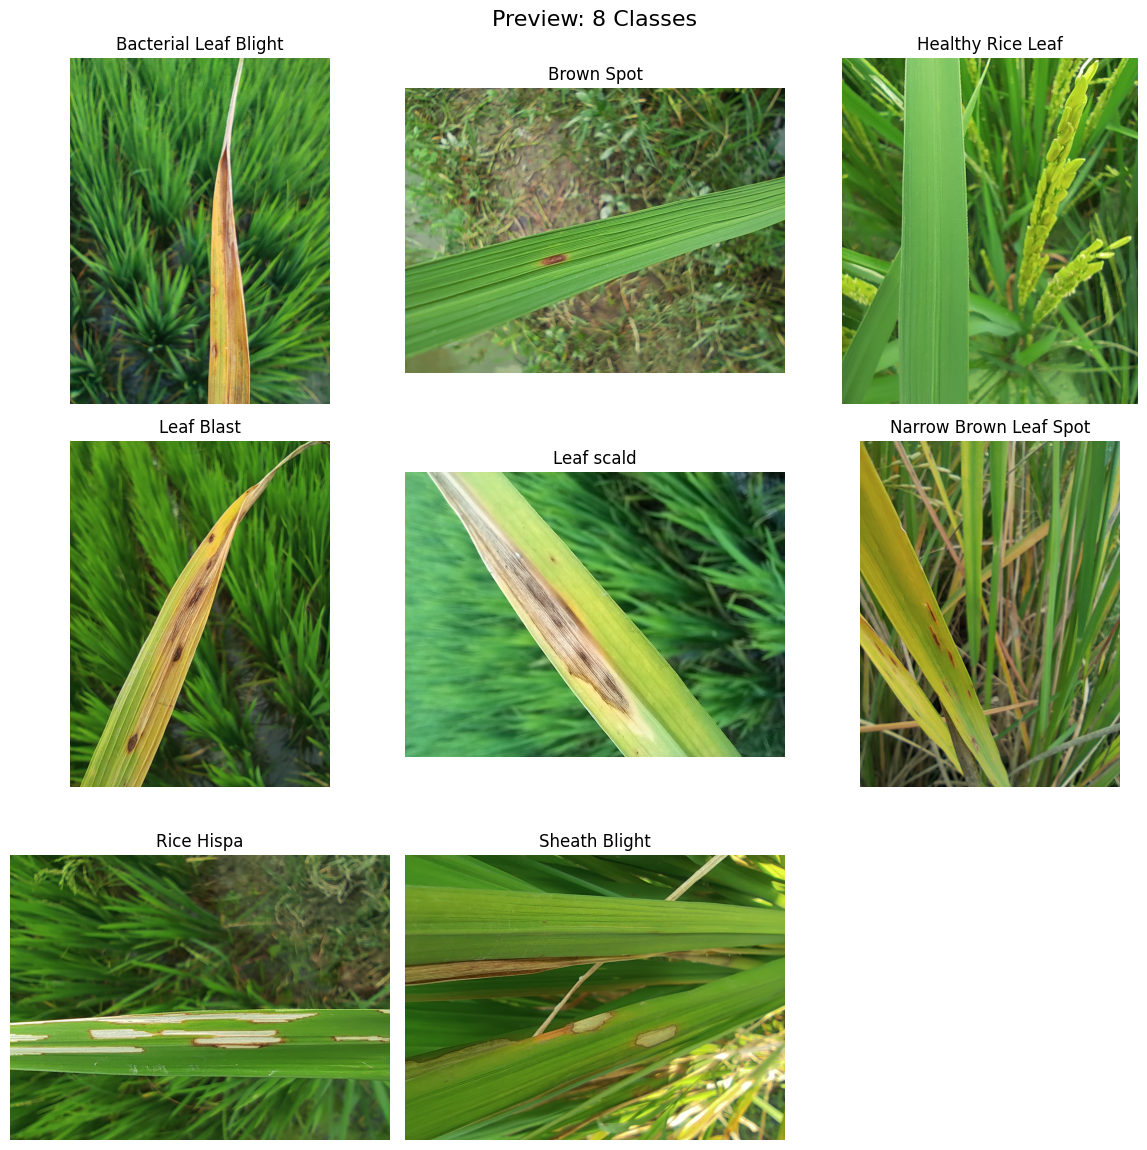

In [2]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os
import math

# ========================
# CONFIG
# ========================
NUM_IMAGES = 8

train_dir = os.path.join(output_dir, "train")
classes = sorted(os.listdir(train_dir))

num_display = min(NUM_IMAGES, len(classes))

cols = int(math.ceil(math.sqrt(num_display)))
rows = int(math.ceil(num_display / cols))

plt.figure(figsize=(cols * 4, rows * 4))

for i, class_name in enumerate(classes[:num_display]):
    class_path = os.path.join(train_dir, class_name)
    
    images = os.listdir(class_path)
    if len(images) == 0:
        continue
    
    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)
    
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle(f"Preview: {num_display} Classes", fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
import torch
import random
import torchvision.transforms.functional as F
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance
import numpy as np
from torchvision.transforms import functional as TF


class RandomShadow:
    def __init__(self, p=0.3):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img = img.convert("RGB")
        w, h = img.size
        overlay = Image.new('L', (w, h), 0)
        draw = ImageDraw.Draw(overlay)

        for _ in range(random.randint(1, 2)):
            x1, x2 = sorted([random.randint(0, w), random.randint(0, w)])
            draw.rectangle([x1, 0, x2, h], fill=random.randint(80, 150))

        shadow = np.array(overlay) / 255.0
        shadow = np.expand_dims(shadow, axis=2)

        img_np = np.array(img).astype(np.float32)
        img_np = img_np * (1 - 0.5 * shadow)  # làm tối
        img_np = np.clip(img_np, 0, 255).astype(np.uint8)

        return Image.fromarray(img_np)


class RandomJPEGCompression:
    def __init__(self, p=0.3):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        quality = random.randint(20, 60)
        from io import BytesIO
        buffer = BytesIO()
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer)


class RandomMotionBlur:
    def __init__(self, p=0.2):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        
        radius = random.uniform(1, 3)
        return img.filter(ImageFilter.GaussianBlur(radius))

class RandomMoirePattern:
    def __init__(self, p=0.35):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        img = img.convert("RGB")
        img_np = np.array(img).astype(np.float32)
        h, w = img_np.shape[:2]
        
        y, x = np.mgrid[0:h, 0:w]
        freq = random.uniform(8, 25)
        angle = random.uniform(0, np.pi)
        moire = np.sin(2 * np.pi * (x * np.cos(angle) + y * np.sin(angle)) / freq)
        moire = (moire + 1) / 2
        
        strength = random.uniform(0.07, 0.20)
        img_np = img_np * (1 - strength * moire[..., None])
        img_np = np.clip(img_np, 0, 255).astype(np.uint8)
        return Image.fromarray(img_np)


class RandomChromaticAberration:
    def __init__(self, p=0.25):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        img = img.convert("RGB")
        r, g, b = img.split()
        
        shift = random.randint(1, 4)
        direction = random.choice([-1, 1])
        
        if random.random() < 0.5:  # shift ngang
            r = TF.affine(r, angle=0, translate=(shift * direction, 0), scale=1.0, shear=0)
            b = TF.affine(b, angle=0, translate=(-shift * direction, 0), scale=1.0, shear=0)
        else:  # shift dọc
            r = TF.affine(r, angle=0, translate=(0, shift * direction), scale=1.0, shear=0)
            b = TF.affine(b, angle=0, translate=(0, -shift * direction), scale=1.0, shear=0)
        
        return Image.merge("RGB", (r, g, b))


class RandomStrongMotionBlur:
    def __init__(self, p=0.25):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        radius = random.uniform(2.5, 6.0)
        angle = random.uniform(0, 360)

        return img.filter(ImageFilter.GaussianBlur(radius))


class RandomColorShiftAndSharpen:
    def __init__(self, p=0.30):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        img = img.convert("RGB")
        
        # Color shift (hue/saturation bias)
        enhancer = ImageEnhance.Color(img)
        img = enhancer.enhance(random.uniform(0.7, 1.8))
        
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(random.uniform(0.8, 1.6))
        
        # Sharpen
        if random.random() < 0.6:
            img = img.filter(ImageFilter.UnsharpMask(radius=2, percent=random.randint(150, 300), threshold=3))
        
        return img


class RandomGridArtifact:
    def __init__(self, p=0.20):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        img = img.convert("RGB")
        w, h = img.size
        draw = ImageDraw.Draw(img)
        
        spacing = random.randint(4, 12)
        thickness = random.randint(1, 2)
        color = random.randint(0, 80)  # dark lines
        
        # Horizontal lines
        if random.random() < 0.6:
            for y in range(0, h, spacing):
                draw.line([(0, y), (w, y)], fill=color, width=thickness)
        # Vertical lines
        if random.random() < 0.6:
            for x in range(0, w, spacing):
                draw.line([(x, 0), (x, h)], fill=color, width=thickness)
        
        return img

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import os
from tqdm import tqdm
import numpy as np

from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import label_binarize

# ========================
# CONFIG
# ========================
data_dir = "/kaggle/working/dataset_split"
batch_size = 8
epochs = 150
lr = 5e-4
weight_decay = 5e-5
img_size = 288
patience = 30
device = "cuda" if torch.cuda.is_available() else "cpu"

# ========================
# TRANSFORM
# ========================
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(0.4, 0.4, 0.3, 0.1),
    transforms.RandomAutocontrast(p=0.3),
    
    RandomShadow(p=0.3),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
    RandomMotionBlur(p=0.2),
    RandomJPEGCompression(p=0.3),
    
    RandomMoirePattern(p=0.35),
    RandomChromaticAberration(p=0.25),
    RandomStrongMotionBlur(p=0.25),
    RandomColorShiftAndSharpen(p=0.30),
    RandomGridArtifact(p=0.20),
    
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    transforms.Lambda(lambda x: x + 0.03 * torch.randn_like(x)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ========================
# DATASET
# ========================
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)

Classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight']


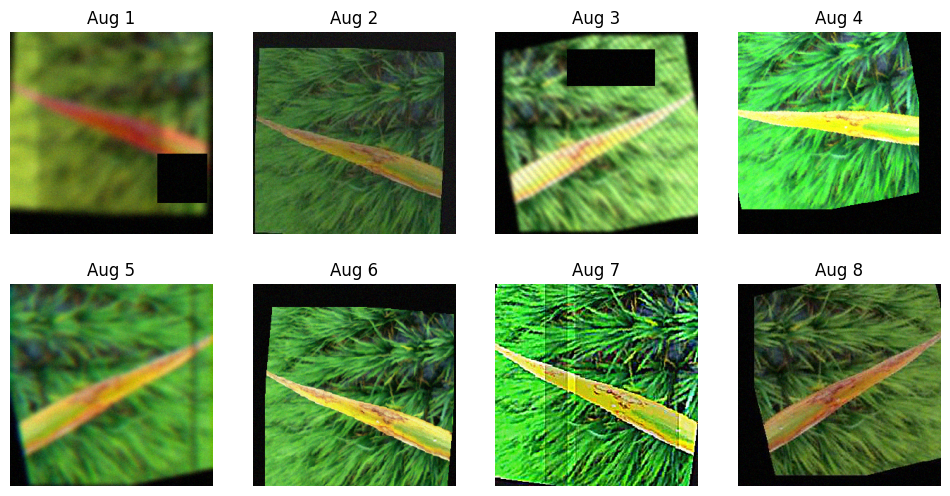

In [5]:
img_path, label = train_dataset.samples[0]

plt.figure(figsize=(12, 6))

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i in range(8):
    img = Image.open(img_path).convert("RGB")
    img = train_transform(img)
    
    img_np = img.permute(1, 2, 0).numpy()
    
    # unnormalize
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_np)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.show()

In [6]:
# ========================
# MODEL
# ========================
model = timm.create_model(
    "efficientnet_b2", 
    pretrained=True, 
    num_classes=num_classes,
    drop_rate=0.35,
    drop_path_rate=0.25
)
model = model.to(device)

# ========================
# MODEL SUMMARY
# ========================
print("="*60)
print("🔍 MODEL ARCHITECTURE SUMMARY")
print("="*60)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model               : EfficientNet-B2")
print(f"Number of classes   : {num_classes}")
print(f"Input size          : {img_size} x {img_size}")
print(f"Device              : {device}")
print(f"Total parameters    : {total_params:,} ({total_params/1e6:.2f} M)")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f} M)")
print("-"*60)

# print("Model Architecture:")
# print(model)

print("\n" + "="*60)
print("✅ Model summary completed!")
print("="*60)

# ========================
# CLASS WEIGHTS (ADD HERE)
# ========================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = [label for _, label in train_dataset.samples]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

for i, w in enumerate(class_weights):
    print(f"{class_names[i]}: {w:.3f}")

# ========================
# LOSS + OPTIMIZER + SCHEDULER
# ========================
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)

optimizer = optim.AdamW(
    model.parameters(), 
    lr=lr, 
    weight_decay=weight_decay
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

# ========================
# TRAINING HISTORY
# ========================
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'val_f1': []
}

best_f1 = 0.0
patience_counter = 0
best_model_path = "/kaggle/working/best_efficientnet_rice_f1.pth"

# ========================
# TRAIN
# ========================
def train_one_epoch():
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc="Training", leave=True)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

# ========================
# VALIDATION (F1-macro)
# ========================
def validate():
    model.eval()
    total_loss = 0
    y_true, y_pred, y_prob = [], [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')

    return avg_loss, accuracy, f1, y_true, y_pred, np.array(y_prob)

# ========================
# MAIN TRAINING LOOP
# ========================
print("🚀 Starting training...\n")

for epoch in range(epochs):
    # Training phase
    train_loss, train_acc = train_one_epoch()
    
    # Validation phase
    val_loss, val_acc, val_f1, y_true, y_pred, y_prob = validate()
    
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    
    current_lr = scheduler.get_last_lr()[0] if hasattr(scheduler, 'get_last_lr') else optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch {epoch+1:3d}/{epochs} | LR: {current_lr:.2e}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | F1-macro: {val_f1:.4f}")
    
    # Early stopping + Save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ BEST MODEL SAVED! F1-macro = {best_f1:.4f}")
    else:
        patience_counter += 1
        print(f"Early stopping counter: {patience_counter}/{patience}")
    
    if patience_counter >= patience:
        print("⛔ Early stopping triggered!")
        break

print(f"\n🎉 Training finished! Best F1-macro: {best_f1:.4f}")

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

🔍 MODEL ARCHITECTURE SUMMARY
Model               : EfficientNet-B2
Number of classes   : 8
Input size          : 288 x 288
Device              : cuda
Total parameters    : 7,712,266 (7.71 M)
Trainable parameters: 7,712,266 (7.71 M)
------------------------------------------------------------

✅ Model summary completed!
Bacterial Leaf Blight: 1.124
Brown Spot: 0.876
Healthy Rice Leaf: 1.313
Leaf Blast: 0.702
Leaf scald: 1.149
Narrow Brown Leaf Spot: 2.023
Rice Hispa: 0.972
Sheath Blight: 0.720
🚀 Starting training...



Training: 100%|██████████| 203/203 [00:40<00:00,  5.06it/s, loss=3.0831]



Epoch   1/150 | LR: 5.00e-04
Train Loss: 2.7650 | Train Acc: 0.2441
Val   Loss: 2.1370 | Val Acc: 0.2721 | F1-macro: 0.2545
✅ BEST MODEL SAVED! F1-macro = 0.2545


Training: 100%|██████████| 203/203 [00:38<00:00,  5.28it/s, loss=1.4674]


...


Epoch 111/150 | LR: 7.97e-05
Train Loss: 0.7224 | Train Acc: 0.9944
Val   Loss: 0.8638 | Val Acc: 0.9461 | F1-macro: 0.9417
Early stopping counter: 28/30


Training: 100%|██████████| 203/203 [00:39<00:00,  5.15it/s, loss=0.5814]



Epoch 112/150 | LR: 7.59e-05
Train Loss: 0.7205 | Train Acc: 0.9975
Val   Loss: 0.8543 | Val Acc: 0.9534 | F1-macro: 0.9496
Early stopping counter: 29/30


Training: 100%|██████████| 203/203 [00:39<00:00,  5.12it/s, loss=1.1978]



Epoch 113/150 | LR: 7.22e-05
Train Loss: 0.7208 | Train Acc: 0.9957
Val   Loss: 0.8580 | Val Acc: 0.9485 | F1-macro: 0.9425
Early stopping counter: 30/30
⛔ Early stopping triggered!

🎉 Training finished! Best F1-macro: 0.9512


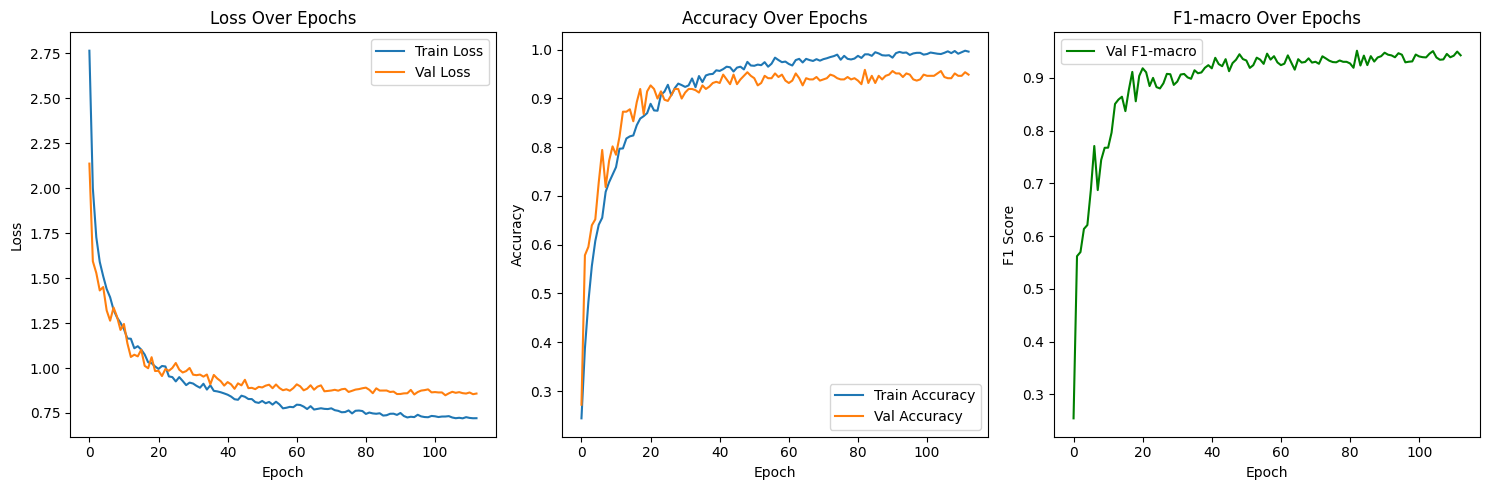

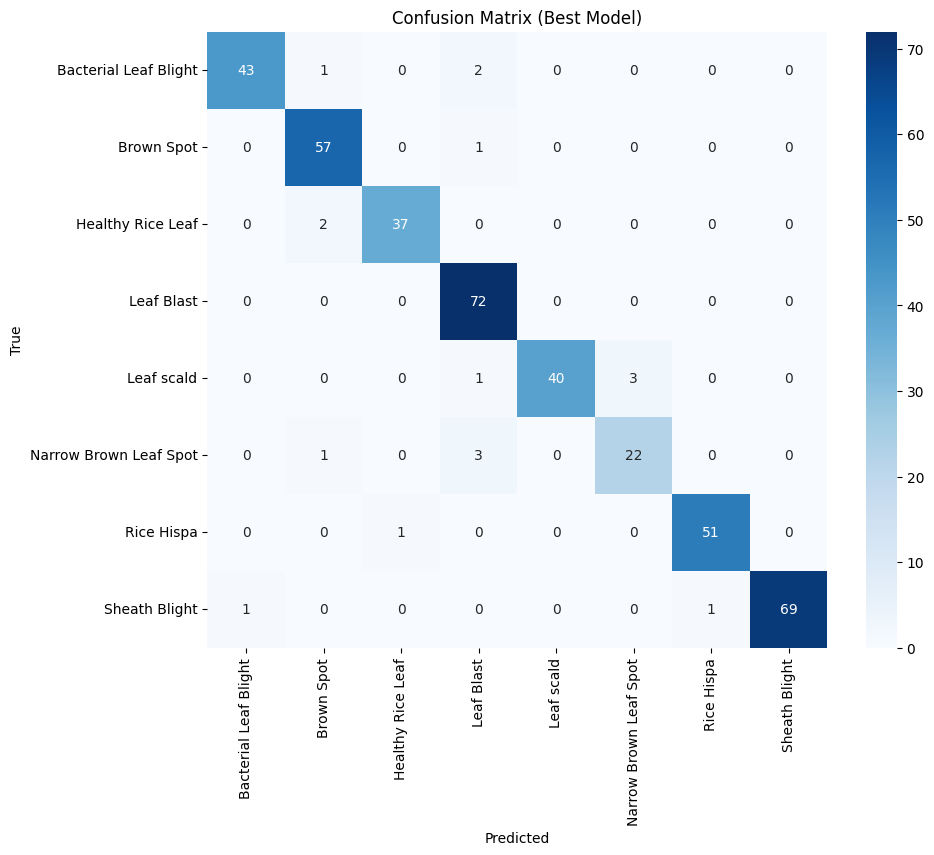

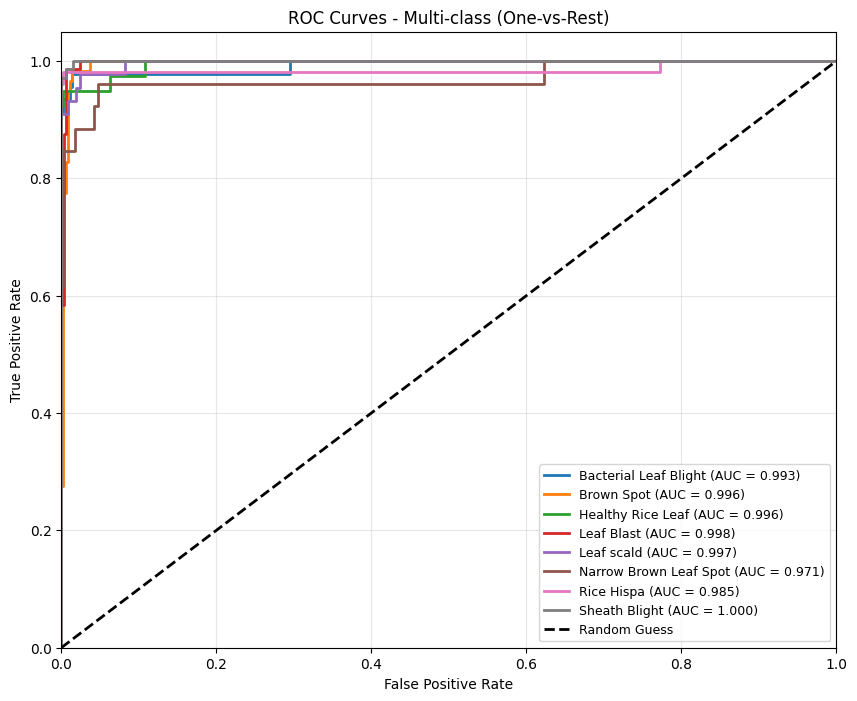

📈 ROC AUC Macro = 0.9920

📊 Final Results on Validation Set:
Best F1-macro : 0.9512
Accuracy      : 0.9583
ROC AUC (macro): 0.9920

📋 Detailed Classification Report:
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.98      0.93      0.96        46
            Brown Spot       0.93      0.98      0.96        58
     Healthy Rice Leaf       0.97      0.95      0.96        39
            Leaf Blast       0.91      1.00      0.95        72
            Leaf scald       1.00      0.91      0.95        44
Narrow Brown Leaf Spot       0.88      0.85      0.86        26
            Rice Hispa       0.98      0.98      0.98        52
         Sheath Blight       1.00      0.97      0.99        71

              accuracy                           0.96       408
             macro avg       0.96      0.95      0.95       408
          weighted avg       0.96      0.96      0.96       408



In [7]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from PIL import Image

# ========================
# PLOTTING RESULTS
# ========================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['val_f1'], label='Val F1-macro', color='green')
plt.title('F1-macro Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

# ========================
# CONFUSION MATRIX + ROC
# ========================
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# Call validate() and get ALL returned values
val_loss, val_acc, val_f1, y_true, y_pred, y_prob = validate()

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# ========================
# ROC CURVE PLOT (Multi-class)
# ========================
y_true_bin = label_binarize(y_true, classes=range(num_classes))

roc_auc = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc_class:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multi-class (One-vs-Rest)')
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

# ========================
# FINAL RESULTS
# ========================
print(f"📈 ROC AUC Macro = {roc_auc:.4f}")

print(f"\n📊 Final Results on Validation Set:")
print(f"Best F1-macro : {best_f1:.4f}")
print(f"Accuracy      : {accuracy_score(y_true, y_pred):.4f}")
print(f"ROC AUC (macro): {roc_auc:.4f}")

print("\n📋 Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [8]:
import torch
import pandas as pd
from torchvision import transforms
from PIL import Image
import os
import timm

# ========================
# CONFIG
# ========================
test_dir = "/kaggle/input/competitions/fptu-can-tho-olympic-ai-2026/test_speedup"
model_path = "/kaggle/working/best_efficientnet_rice_f1.pth"
output_csv = "/kaggle/working/my_submission.csv"
img_size = 288
device = "cuda" if torch.cuda.is_available() else "cpu"

# ========================
# CLASS NAMES (same with TRAIN)
# ========================
class_names = [
    "Bacterial Leaf Blight",
    "Brown Spot",
    "Healthy Rice Leaf",
    "Leaf Blast",
    "Leaf scald",
    "Narrow Brown Leaf Spot",
    "Rice Hispa",
    "Sheath Blight"
]

num_classes = len(class_names)

# ========================
# LOAD MODEL
# ========================
model = timm.create_model(
    "efficientnet_b2", 
    pretrained=False, 
    num_classes=num_classes,
    drop_rate=0.35,
    drop_path_rate=0.25
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# ========================
# TRANSFORM
# ========================
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ========================
# PREDICT
# ========================
results = []

image_files = sorted(os.listdir(test_dir))

for img_name in image_files:
    img_path = os.path.join(test_dir, img_name)

    if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
        continue

    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    results.append([img_name, pred.item()])

# ========================
# SAVE CSV
# ========================
df = pd.DataFrame(results, columns=["image_id", "label"])
df.to_csv(output_csv, index=False)

print(f"✅ Saved submission file: {output_csv}")

✅ Saved submission file: /kaggle/working/my_submission.csv


/tmp/ipykernel_23/3356436994.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_23/3356436994.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


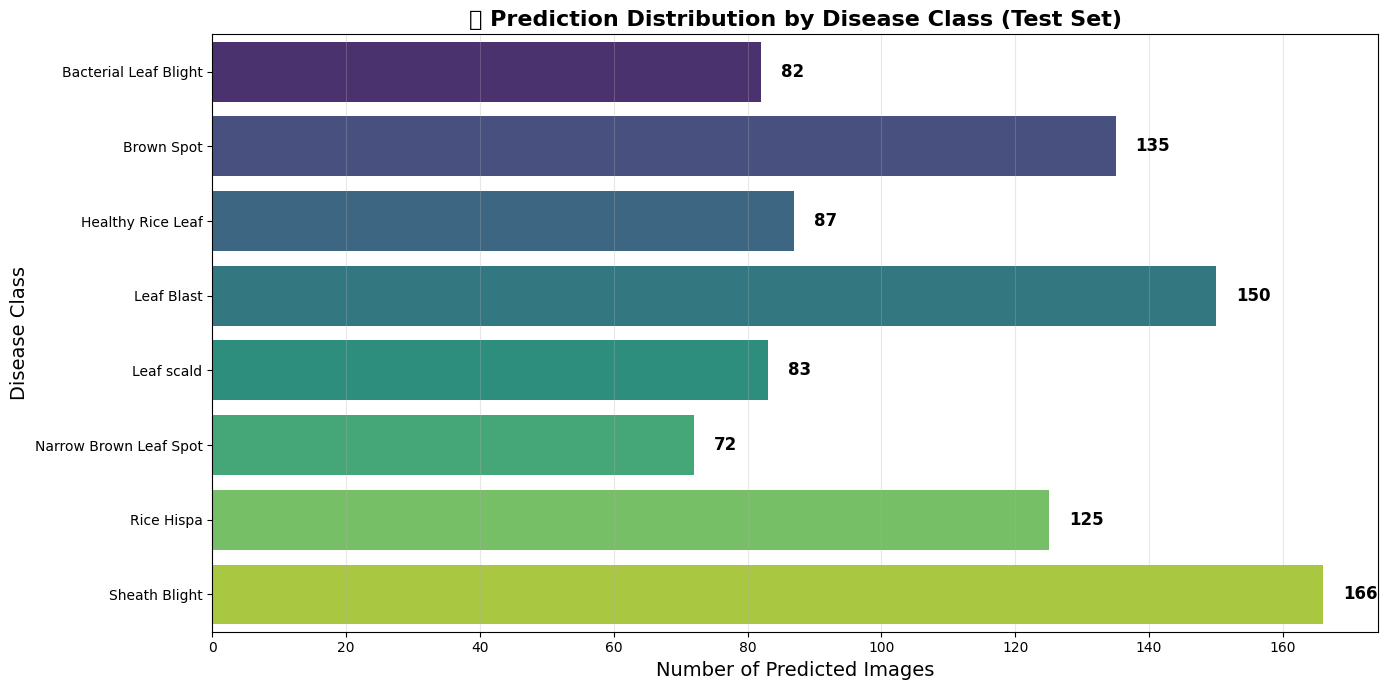


📋 Prediction Distribution on Test Set:
Bacterial Leaf Blight      82
Brown Spot                135
Healthy Rice Leaf          87
Leaf Blast                150
Leaf scald                 83
Narrow Brown Leaf Spot     72
Rice Hispa                125
Sheath Blight             166

✅ Total test images: 900
   Number of classes with predictions: 8 / 8


In [9]:
# ========================
# BAR CHART: NUMBER OF PREDICTIONS PER CLASS
# ========================
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of predictions per class
pred_counts = df['label'].value_counts().sort_index()

# Map numeric label → class name
pred_counts.index = [class_names[i] for i in pred_counts.index]

# ========================
# PLOT BAR CHART
# ========================
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=pred_counts.values,
    y=pred_counts.index,
    palette="viridis"
)

plt.title('📊 Prediction Distribution by Disease Class (Test Set)',
          fontsize=16, fontweight='bold')
plt.xlabel('Number of Predicted Images', fontsize=14)
plt.ylabel('Disease Class', fontsize=14)
plt.grid(axis='x', alpha=0.3)

# Display exact count on each bar
for i, count in enumerate(pred_counts.values):
    ax.text(count + 3, i, str(count),
            va='center', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# ========================
# PRINT SUMMARY TABLE
# ========================
print("\n📋 Prediction Distribution on Test Set:")
print(pred_counts.to_string())

print(f"\n✅ Total test images: {len(df)}")
print(f"   Number of classes with predictions: {len(pred_counts)} / {num_classes}")